# Cluster dataset: uniform vs motif-seeded sampling

Two UMA-labelled benzene cluster campaigns, generated to train a Δ-learning AniSOAP
correction. They are configured identically except for `orientation_sampling`.

Analysis functions live in `asmcmc/data_preparation/cluster_analysis.py`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, LogNorm, TwoSlopeNorm

from asmcmc.data_preparation.cluster_analysis import (
    COFACIAL, FAR_SLIPPED, PARALLEL_DISPLACED, T_SHAPED, EV_TO_KCAL,
    frame_records, gb_invariants, hard_core_pass_rate, load_campaign,
    mc_pair_reference, motif_masks, pair_records, qa_report, radial_profile,
    reweighting_ess, stack_coordinates, three_body_records, weight_diagnostics,
)

%matplotlib inline

CAMPAIGNS = {
    "uniform": "../results/cluster_pilot",
    "motif":   "../results/cluster_train",
}
# The converged 100 K herringbone run (HB->SP endpoint, V/mol 96.5 A^3): the pair
# geometries the sampler actually asks the potential about.
MC_DB = "../results/validation/100.0_6.324209e-07/herringbone_jittered_2/simulation.db"

# Categorical slots in fixed order, assigned per entity: 'uniform' is blue and 'motif'
# is orange in every figure below, never cycled.
COLOUR = {"uniform": "#2a78d6", "motif": "#eb6834"}
C_ACCENT = "#1baf7a"

plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 9,
})

campaigns, records, frames_by = {}, {}, {}
for label, path in CAMPAIGNS.items():
    frames, config = load_campaign(path)
    frames_by[label] = frames
    campaigns[label] = config
    records[label] = pair_records(frames)

LABELS = list(CAMPAIGNS)
for label in LABELS:
    settings = campaigns[label]["settings"]
    # The pilot predates the orientation_sampling field, so its absence *is* "uniform".
    orientation = settings.get("orientation_sampling", "uniform")
    print(f"{label:8s} {len(frames_by[label]):4d} frames  "
          f"seed0={campaigns[label]['seed0']}  "
          f"orientation={orientation:8s} "
          f"radial={settings['radial_sampling']}  "
          f"uniform_weight={settings.get('uniform_weight', '-')}")

uniform   500 frames  seed0=20260731  orientation=uniform  radial=mixture  uniform_weight=-
motif    5000 frames  seed0=20260901  orientation=motif    radial=mixture  uniform_weight=0.56


## 1. QA

Nothing below is worth reading if either campaign is unsound. The many-body checks are
exact-arithmetic identities, not tolerances: the generator *defines* `three_body_energy` as
`E₁₂₃ − Σ E_ij + Σ E_i`, so a nonzero residual means the stored fields disagree with each
other. The GBQ baseline check is what licenses §5 to attribute a trimer's cluster-summed
baseline to its individual pairs.

In [2]:
reports = {label: qa_report(frames_by[label], campaigns[label]) for label in LABELS}

rows = [
    ("frames", lambda q: f"{q.n_frames}"),
    ("dimers / trimers", lambda q: f"{q.n_dimers} / {q.n_trimers}"),
    ("labelled pairs", lambda q: f"{q.n_pairs}"),
    ("unique (shard, config_index)", lambda q: "yes" if q.unique_ids else "NO"),
    ("monomer reference spread (eV)", lambda q: f"{q.monomer_energy_spread:.1e}"),
    ("min inter-molecular atom distance (A)", lambda q: f"{q.min_atom_distance:.4f}"),
    ("hard-core violations", lambda q: f"{q.hard_core_violations}"),
    ("three-body algebra residual (eV)", lambda q: f"{q.three_body_max_error:.1e}"),
    ("pair-interaction algebra residual (eV)", lambda q: f"{q.pair_algebra_max_error:.1e}"),
    ("GBQ baseline rebuild error (eV)", lambda q: f"{q.baseline_max_error:.1e}"),
    ("duplicate configurations", lambda q: f"{q.duplicate_signatures}"),
    ("non-finite frames", lambda q: f"{q.non_finite_frames}"),
]
width = max(len(r[0]) for r in rows)
print(f"{'':<{width}}  " + "".join(f"{label:>12s}" for label in LABELS))
print("-" * (width + 2 + 12 * len(LABELS)))
for name, fn in rows:
    print(f"{name:<{width}}  " + "".join(f"{fn(reports[l]):>12s}" for l in LABELS))

print()
for label in LABELS:
    report = reports[label]
    print(f"{label:8s} {'PASS' if report.ok else 'FAIL: ' + '; '.join(report.problems)}")

                                             uniform       motif
----------------------------------------------------------------
frames                                           500        5000
dimers / trimers                           156 / 344 1550 / 3450
labelled pairs                                  1188       11900
unique (shard, config_index)                     yes         yes
monomer reference spread (eV)                0.0e+00     0.0e+00
min inter-molecular atom distance (A)         2.4073      2.4001
hard-core violations                               0           0
three-body algebra residual (eV)             0.0e+00     0.0e+00
pair-interaction algebra residual (eV)       0.0e+00     0.0e+00
GBQ baseline rebuild error (eV)              3.6e-16     8.4e-16
duplicate configurations                           0           0
non-finite frames                                  0           0

uniform  PASS
motif    PASS


## 2. What the campaigns contain

**A campaign holds far more pair labels than frames.** Every trimer stores
`pair_interaction_energies` computed by genuine MLIP calls on its three 2-molecule subsets,
so each trimer yields three labelled pair interaction energies and each dimer one.

In [3]:
print(f"{'':<26}" + "".join(f"{label:>12s}" for label in LABELS))
print("-" * (26 + 12 * len(LABELS)))
for name, fn in [
    ("frames", lambda r, f: f"{len(f)}"),
    ("pair labels", lambda r, f: f"{len(r['r'])}"),
    ("  from sampled dimers", lambda r, f: f"{int((r['n_molecules'] == 2).sum())}"),
    ("  from trimer subsets", lambda r, f: f"{int((r['n_molecules'] == 3).sum())}"),
    ("pairs per frame", lambda r, f: f"{len(r['r']) / len(f):.2f}"),
    ("median separation (A)", lambda r, f: f"{np.median(r['r']):.2f}"),
]:
    print(f"{name:<26}" + "".join(f"{fn(records[l], frames_by[l]):>12s}" for l in LABELS))

                               uniform       motif
--------------------------------------------------
frames                             500        5000
pair labels                       1188       11900
  from sampled dimers              156        1550
  from trimer subsets             1032       10350
pairs per frame                   2.38        2.38
median separation (A)            10.99        8.86


## 3. Why motif seeding exists

`compact_probability = 0.7` aimed 70% of the uniform campaign's radial draws into
3.4–6 Å, but only 25% of its pairs landed there. The draws were rejected by the hard core and redrawn, since at close approach two benzenes in a random
relative orientation almost always clash.

  r (A)    random   cofacial    gain
------------------------------------
    3.4      1.7%      76.4%     46x
    3.6      3.5%      85.7%     25x
    4.0      5.9%      93.8%     16x
    4.5     15.1%      98.9%      7x
    4.7     19.7%      99.8%      5x
    5.0     32.2%      99.8%      3x
    5.5     51.1%      99.9%      2x
    6.0     65.4%     100.0%      2x
    7.0     96.1%     100.0%      1x
    8.0    100.0%     100.0%      1x


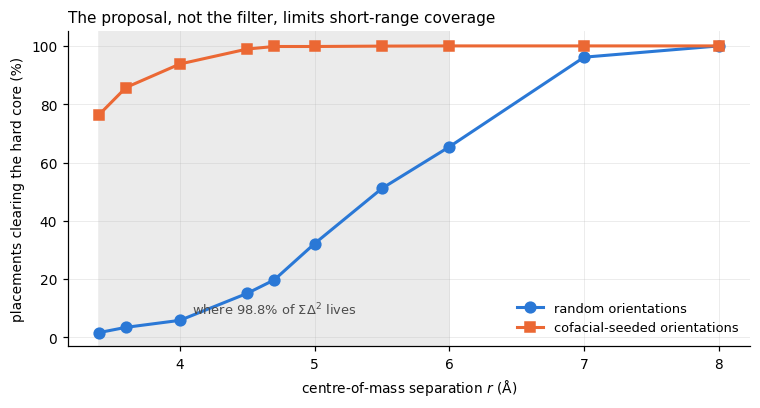

In [4]:
probe = np.array([3.4, 3.6, 4.0, 4.5, 4.7, 5.0, 5.5, 6.0, 7.0, 8.0])
rate_random = hard_core_pass_rate(probe, n_trials=1500, seed=0)
rate_cofacial = hard_core_pass_rate(probe, orientations="cofacial", n_trials=1500, seed=0)

print(f"{'r (A)':>7}{'random':>10}{'cofacial':>11}{'gain':>8}")
print("-" * 36)
for r, a, b in zip(probe, rate_random, rate_cofacial):
    print(f"{r:>7.1f}{100*a:>9.1f}%{100*b:>10.1f}%{(f'{b/a:.0f}x' if a > 0 else '-'):>8}")

fig, ax = plt.subplots(figsize=(6.8, 3.6), constrained_layout=True)
ax.axvspan(3.4, 6.0, color="0.92", zorder=0)
ax.plot(probe, 100 * rate_random, "o-", color=COLOUR["uniform"], lw=2, ms=7,
        label="random orientations")
ax.plot(probe, 100 * rate_cofacial, "s-", color=COLOUR["motif"], lw=2, ms=7,
        label="cofacial-seeded orientations")
ax.annotate("where 98.8% of $\\Sigma\\Delta^2$ lives", xy=(4.7, 8), fontsize=8.5,
            color="0.3", ha="center")
ax.set_xlabel("centre-of-mass separation $r$ ($\\mathrm{\\AA}$)")
ax.set_ylabel("placements clearing the hard core (%)")
ax.set_title("The proposal, not the filter, limits short-range coverage",
             fontsize=10, loc="left")
ax.legend(frameon=False, fontsize=8.5, loc="lower right")
ax.set_ylim(-3, 105)
plt.show()

At 3.6 Å a random orientation clears the hard core ~3% of the time, whereas a cofacial-seeded 
one clears at a rate of ~86%. Since position and orientation are coupled by the hard core, 
they have to be proposed together.

## 4. Did it work?

The headline. Shares of all labelled pairs, so the slightly different pair totals do not
matter.

In [5]:
def share(label, mask):
    return 100 * mask.mean()

shells = [(3.4, 5), (5, 6), (6, 7), (7, 9), (9, 15), (15, np.inf)]
print(f"{'share of pairs':<24}" + "".join(f"{l:>10s}" for l in LABELS) + f"{'change':>10s}")
print("-" * (24 + 10 * len(LABELS) + 10))
for lo, hi in shells:
    vals = [share(l, (records[l]["r"] >= lo) & (records[l]["r"] < hi)) for l in LABELS]
    name = f"  {lo:.1f}-{hi:.0f} A" if np.isfinite(hi) else f"  >{lo:.0f} A"
    print(f"{name:<24}" + "".join(f"{v:>9.1f}%" for v in vals)
          + f"{vals[1] - vals[0]:>+9.1f}")

print()
print(f"{'motif share (3.4-6 A)':<24}" + "".join(f"{l:>10s}" for l in LABELS) + f"{'change':>10s}")
print("-" * (24 + 10 * len(LABELS) + 10))
masks = {l: motif_masks(records[l]) for l in LABELS}
for name in (COFACIAL, PARALLEL_DISPLACED, FAR_SLIPPED, T_SHAPED):
    vals = [share(l, masks[l][name]) for l in LABELS]
    counts = [int(masks[l][name].sum()) for l in LABELS]
    print(f"  {name:<22}" + "".join(f"{v:>9.1f}%" for v in vals)
          + f"{vals[1] - vals[0]:>+9.1f}")
    print(f"{'':<24}" + "".join(f"{'(n=' + str(c) + ')':>10s}" for c in counts))

share of pairs             uniform     motif    change
------------------------------------------------------
  3.4-5 A                    11.1%     15.6%     +4.5
  5.0-6 A                    14.2%     19.4%     +5.1
  6.0-7 A                     2.2%      6.9%     +4.7
  7.0-9 A                     8.5%      8.7%     +0.2
  9.0-15 A                   52.5%     41.1%    -11.4
  >15 A                      11.4%      8.3%     -3.2

motif share (3.4-6 A)      uniform     motif    change
------------------------------------------------------
  cofacial                    1.1%      4.2%     +3.1
                            (n=13)   (n=500)
  parallel-displaced          5.2%     10.9%     +5.6
                            (n=62)  (n=1292)
  far-slipped                 2.5%      3.6%     +1.1
                            (n=30)   (n=429)
  T-shaped                    2.9%      6.3%     +3.4
                            (n=34)   (n=747)


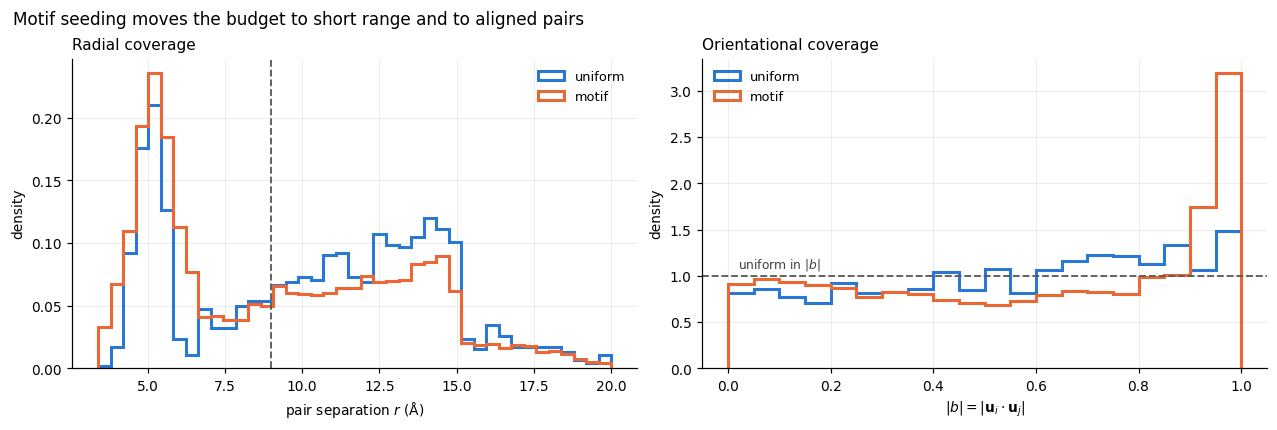

In [6]:
fig, (ax_r, ax_b) = plt.subplots(1, 2, figsize=(11.5, 3.8), constrained_layout=True)

r_edges = np.linspace(3.4, 20, 42)
for label in LABELS:
    ax_r.hist(records[label]["r"], bins=r_edges, density=True, histtype="step",
              lw=2, color=COLOUR[label], label=label)
ax_r.axvline(9.0, color="0.35", ls="--", lw=1.2)
ax_r.set_xlabel("pair separation $r$ ($\\mathrm{\\AA}$)")
ax_r.set_ylabel("density")
ax_r.set_title("Radial coverage", fontsize=10, loc="left")
ax_r.legend(frameon=False, fontsize=8.5)

b_edges = np.linspace(0, 1, 21)
for label in LABELS:
    abs_b, _, _ = gb_invariants(records[label])
    ax_b.hist(abs_b, bins=b_edges, density=True, histtype="step", lw=2,
              color=COLOUR[label], label=label)
ax_b.axhline(1.0, color="0.35", ls="--", lw=1.2)
ax_b.annotate("uniform in $|b|$", xy=(0.02, 1.0), xytext=(0, 5),
              textcoords="offset points", fontsize=8, color="0.25")
ax_b.set_xlabel("$|b| = |\\mathbf{u}_i \\cdot \\mathbf{u}_j|$")
ax_b.set_ylabel("density")
ax_b.set_title("Orientational coverage", fontsize=10, loc="left")
ax_b.legend(frameon=False, fontsize=8.5)

fig.suptitle("Motif seeding moves the budget to short range and to aligned pairs",
             fontsize=11, x=0.005, ha="left")
plt.show()

## 5. Coverage against what the sampler visits

The dataset exists because the condensed-phase training set is orientationally degenerate.
The test that matters is whether it covers the pair geometries an MC run actually reaches.

A caveat governs the maps: there are orders of magnitude fewer cluster pairs than MC pairs
(both counts are printed above), so on a fine grid most empty cluster bins would be empty
from *sample size*, not from a real gap. Bins are kept coarse, and the third panel is a
**density ratio**, invariant to the sample sizes because both sides are normalised first.

MC reference: 700874 pairs from 12 frames


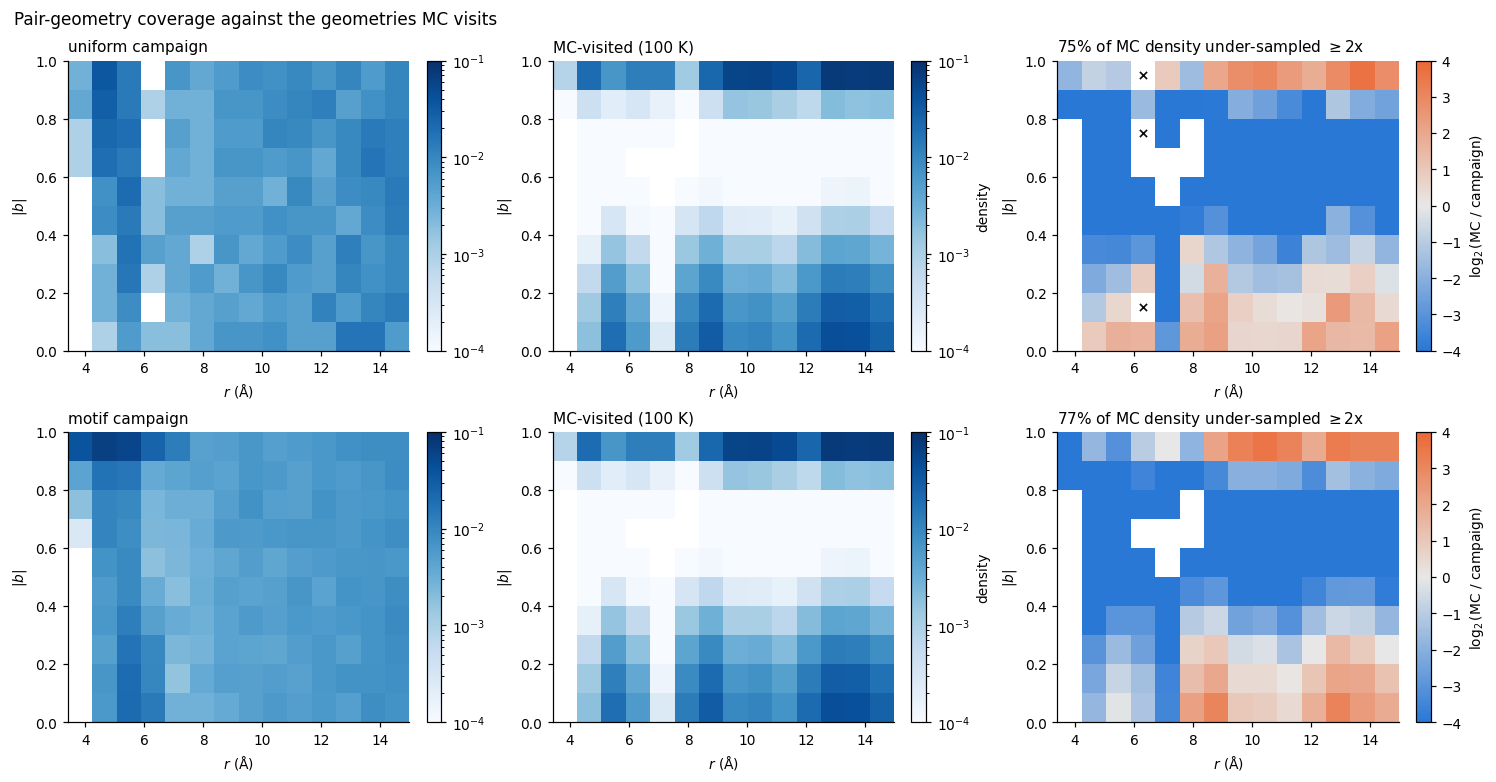

In [7]:
mc = mc_pair_reference(MC_DB, n_frames=12, cutoff=15.0)
mc_records = {**mc, "n_molecules": np.full(len(mc["r"]), 2)}
mc_b, mc_a_hi, _ = gb_invariants(mc_records)
print(f"MC reference: {len(mc['r'])} pairs from {mc['n_frames']} frames")

r_edges = np.linspace(3.4, 15.0, 15)
b_edges = np.linspace(0.0, 1.0, 11)
ratio_cmap = LinearSegmentedColormap.from_list(
    "cluster_mc", [COLOUR["uniform"], "#e8e8e6", COLOUR["motif"]])

fig, axs = plt.subplots(2, 3, figsize=(13.5, 7.0), constrained_layout=True)
norm = LogNorm(vmin=1e-4, vmax=1e-1)
ratio_norm = TwoSlopeNorm(vmin=-4, vcenter=0.0, vmax=4)


def density(x, y, xe, ye):
    counts, _, _ = np.histogram2d(x, y, bins=[xe, ye])
    return (counts / counts.sum()).T, counts.T


d_mc, n_mc = density(mc["r"], mc_b, r_edges, b_edges)

for row, label in enumerate(LABELS):
    abs_b, _, _ = gb_invariants(records[label])
    d_c, n_c = density(records[label]["r"], abs_b, r_edges, b_edges)

    im = axs[row, 0].pcolormesh(r_edges, b_edges, np.where(d_c > 0, d_c, np.nan),
                                cmap="Blues", norm=norm)
    axs[row, 0].set_title(f"{label} campaign", fontsize=10, loc="left")
    fig.colorbar(im, ax=axs[row, 0])

    im = axs[row, 1].pcolormesh(r_edges, b_edges, np.where(d_mc > 0, d_mc, np.nan),
                                cmap="Blues", norm=norm)
    axs[row, 1].set_title("MC-visited (100 K)", fontsize=10, loc="left")
    fig.colorbar(im, ax=axs[row, 1], label="density")

    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.log2(np.where(d_mc > 0, d_mc, np.nan) / np.where(d_c > 0, d_c, np.nan))
    im = axs[row, 2].pcolormesh(r_edges, b_edges, ratio, cmap=ratio_cmap, norm=ratio_norm)
    under = 100 * np.nansum(np.where(ratio > 1, d_mc, 0))
    axs[row, 2].set_title(f"{under:.0f}% of MC density under-sampled $\\geq$2x",
                          fontsize=10, loc="left")
    fig.colorbar(im, ax=axs[row, 2], label="$\\log_2$(MC / campaign)")

    gap = (n_c == 0) & (n_mc > 0)
    ys, xs = np.nonzero(gap)
    axs[row, 2].scatter((r_edges[:-1] + r_edges[1:])[xs] / 2,
                        (b_edges[:-1] + b_edges[1:])[ys] / 2,
                        marker="x", s=22, color="#0b0b0b", linewidth=1.1, zorder=4)

    for ax in axs[row]:
        ax.set_xlabel("$r$ ($\\mathrm{\\AA}$)")
        ax.set_ylabel("$|b|$")
        ax.grid(False)

fig.suptitle("Pair-geometry coverage against the geometries MC visits",
             fontsize=11, x=0.005, ha="left")
plt.show()

In [8]:
def total_variation(x, y, edges):
    a, _ = np.histogram(x, bins=edges)
    b, _ = np.histogram(y, bins=edges)
    return 0.5 * np.abs(a / a.sum() - b / b.sum()).sum()

b_marg = np.linspace(0, 1, 11)
r_marg = np.linspace(3.4, 15.0, 24)
mc_well = mc["r"] < 6.0

print("Total-variation distance to the MC marginal (0 = identical):")
print(f"{'campaign':<10}{'|b| all':>10}{'|b| r<6':>10}{'r':>10}")
print("-" * 40)
for label in LABELS:
    abs_b, _, _ = gb_invariants(records[label])
    inside = (records[label]["r"] >= 3.4) & (records[label]["r"] <= 15.0)
    well = records[label]["r"] < 6.0
    print(f"{label:<10}"
          f"{total_variation(abs_b, mc_b, b_marg):>10.3f}"
          f"{total_variation(abs_b[well], mc_b[mc_well], b_marg):>10.3f}"
          f"{total_variation(records[label]['r'][inside], mc['r'], r_marg):>10.3f}")

Total-variation distance to the MC marginal (0 = identical):
campaign     |b| all   |b| r<6         r
----------------------------------------
uniform        0.604     0.643     0.261
motif          0.457     0.348     0.383


The MC density is **bimodal in `|b|`** — mass at high `|b|` (aligned stacks) and at low
`|b|` (edge-on contacts), with little between. That is what a herringbone /
slipped-parallel crystal is made of, and uniform sampling is flat in `|b|` by construction,
so it spends most of its budget in the orientational middle the crystal barely visits.

**The trade is explicit, and it is not all improvement.** Motif seeding moves the
orientational distribution markedly *toward* the MC's, most of all in the well region. It
moves the *radial* distribution *away*, because it deliberately spends budget at short range
while the MC's radial mass sits at long range.

That radial mismatch is what drives the "% under-sampled ≥2×" figure *up* and the census ESS
in §8 *down*. It is a deliberate choice, not a regression: §6 shows the far field is already
correct under the baseline, so budget spent matching its census buys no learnable signal.

Both campaigns retain **complete radial support** — no shell the MC occupies is empty in
either — which is the property reweighting cannot restore, and what the defensive uniform
component exists to protect.

## 6. What the correction has to learn

`Δ = E_UMA − E_GBQ` is the function an AniSOAP correction fits. Its size and localisation
are properties of the two energy models, not of the sampling — so these hold for both
campaigns. What sampling changes is how much of the budget lands where Δ is large.

In [9]:
for label in LABELS:
    profile = radial_profile(records[label])
    delta = records[label]["delta"] * EV_TO_KCAL
    within_9 = records[label]["r"] <= 9.0
    share_9 = (delta[within_9] ** 2).sum() / (delta ** 2).sum()

    print(f"--- {label} ---")
    header = (f"{'shell (A)':<13}{'n':>6}{'% pairs':>9}{'D rms':>9}"
              f"{'D max':>9}{'% of SD^2':>11}")
    print(header)
    for row in profile:
        hi = "inf" if not np.isfinite(row["r_hi"]) else f"{row['r_hi']:.1f}"
        print(f"{row['r_lo']:>5.1f}-{hi:<7}{row['count']:>6}"
              f"{100*row['fraction']:>8.1f}%{row['delta_rms']:>9.3f}"
              f"{row['delta_absmax']:>9.3f}{100*row['delta_sq_share']:>10.2f}%")
    print(f"  r <= 9 A: {int(within_9.sum())}/{len(records[label]['r'])} pairs "
          f"({100*within_9.mean():.0f}%), {100*share_9:.1f}% of total Delta^2")
    print()
print("(energies in kcal/mol)")

--- uniform ---
shell (A)         n  % pairs    D rms    D max  % of SD^2
  3.4-5.0       132    11.1%    1.100    6.892     87.50%
  5.0-6.0       169    14.2%    0.350    0.815     11.33%
  6.0-7.0        26     2.2%    0.189    0.368      0.51%
  7.0-9.0       101     8.5%    0.094    0.282      0.49%
  9.0-15.0      624    52.5%    0.022    0.094      0.17%
 15.0-inf       136    11.4%    0.002    0.004      0.00%
  r <= 9 A: 428/1188 pairs (36%), 99.8% of total Delta^2

--- motif ---
shell (A)         n  % pairs    D rms    D max  % of SD^2
  3.4-5.0      1858    15.6%    0.807    8.134     77.60%
  5.0-6.0      2304    19.4%    0.351    1.183     18.23%
  6.0-7.0       819     6.9%    0.216    0.742      2.46%
  7.0-9.0      1032     8.7%    0.091    0.289      0.54%
  9.0-15.0     4891    41.1%    0.023    0.095      0.17%
 15.0-inf       983     8.3%    0.002    0.004      0.00%
  r <= 9 A: 6026/11900 pairs (51%), 99.8% of total Delta^2

(energies in kcal/mol)


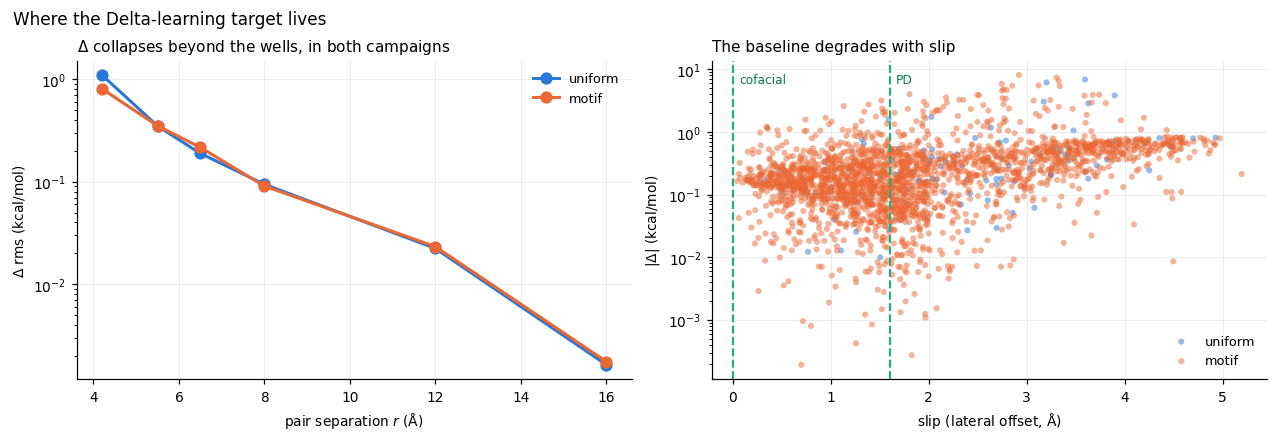

In [10]:
fig, (ax_r, ax_s) = plt.subplots(1, 2, figsize=(11.5, 3.9), constrained_layout=True)

for label in LABELS:
    profile = radial_profile(records[label])
    centres = [0.5 * (row["r_lo"] + min(row["r_hi"], 17.0)) for row in profile]
    ax_r.plot(centres, [row["delta_rms"] for row in profile], "o-",
              color=COLOUR[label], lw=2, ms=7, label=label)
ax_r.set_yscale("log")
ax_r.set_xlabel("pair separation $r$ ($\\mathrm{\\AA}$)")
ax_r.set_ylabel("$\\Delta$ rms (kcal/mol)")
ax_r.set_title("$\\Delta$ collapses beyond the wells, in both campaigns",
               fontsize=10, loc="left")
ax_r.legend(frameon=False, fontsize=8.5)

for label in LABELS:
    _, slip = stack_coordinates(records[label])
    abs_b, _, _ = gb_invariants(records[label])
    parallel = ((records[label]["r"] >= 3.4) & (records[label]["r"] < 6.0)
                & (abs_b > 0.8))
    ax_s.scatter(slip[parallel], np.abs(records[label]["delta"][parallel] * EV_TO_KCAL),
                 s=16, alpha=0.5, color=COLOUR[label], edgecolors="none", label=label)
for x, text in [(0.0, "cofacial"), (1.6, "PD")]:
    ax_s.axvline(x, color=C_ACCENT, ls="--", lw=1.4)
    ax_s.annotate(text, xy=(x, 0.96), xycoords=("data", "axes fraction"),
                  xytext=(4, 0), textcoords="offset points", fontsize=8,
                  color="#0d7a55", va="top")
ax_s.set_yscale("log")
ax_s.set_xlabel("slip (lateral offset, $\\mathrm{\\AA}$)")
ax_s.set_ylabel("$|\\Delta|$ (kcal/mol)")
ax_s.set_title("The baseline degrades with slip", fontsize=10, loc="left")
ax_s.legend(frameon=False, fontsize=8.5, loc="lower right")

fig.suptitle("Where the Delta-learning target lives", fontsize=11, x=0.005, ha="left")
plt.show()

**Δ is almost entirely localised inside 9 Å** in both campaigns, collapsing by orders of
magnitude from the wells to the far field, where GB+Q and UMA agree to well under any fit's
target accuracy.

This is the honest form of the budget argument. The far field is *physically* important — a
100 K MC frame puts most of its pairs beyond 9 Å, carrying a real share of cohesion — but it
is already correct under the baseline, so there is nothing there for a Δ model to learn.

**Δ grows with slip**: cofacial → PD → far-slipped. Near-parallel pairs are one continuous
family separated by *slip*, not by `a_hi`. The Cacelli reference minima make the point:
cofacial and PD sit at essentially the same stacking height (3.90 vs 3.50 Å) and differ only
in lateral offset (0.0 vs 1.6 Å), and PD's `a_hi` is 0.909, barely below cofacial's 1.0.
*(External reference values from `proposals.motif_reference()`, not campaign-derived.)*

**One result worth reading carefully.** Compare the two campaigns' Δ rms *and* Δ max in
3.4–5 Å above. The uniform campaign's few short-range survivors are, by selection, unusual
near-clash geometries that happened to thread the hard core, and those are where the GB+Q
functional form diverges most violently from UMA; motif proposals sit near physically
realisable contacts instead. A milder short-range Δ rms is therefore defensible — the
correction has to be accurate where the MC actually goes, not at pathological geometries.
Read Δ *max* with sample size in mind, though: the larger campaign draws more rare extremes
simply by having more draws, so the two columns are not comparable on that row.

Either way it means **the defensive uniform component is also what keeps the odd high-Δ
geometry in the set**, which is one more reason not to drive its weight to zero.

## 7. Three-body

69% of frames are trimers, each costing 4 MLIP calls against a dimer's 1. §2 showed that
buys 3 pair labels, not 1, so it is not wasted — but the *stated* reason for trimers is the
three-body term. Is it worth anything, and did compact sampling change it?

In [11]:
print(f"{'':<38}" + "".join(f"{l:>12s}" for l in LABELS))
print("-" * (38 + 12 * len(LABELS)))
tb = {l: three_body_records(frames_by[l]) for l in LABELS}
for name, fn in [
    ("trimers", lambda t: f"{len(t)}"),
    ("three-body rms (kcal/mol)", lambda t: f"{t.rms():.4f}"),
    ("  as a fraction of pair-sum rms", lambda t: f"{t.relative_rms():.4f}"),
    ("compact trimers (all pairs < 7 A)", lambda t: f"{int(t.compact().sum())}"),
    ("  as a share of trimers", lambda t: f"{100*t.compact().mean():.1f}%"),
    ("  their three-body rms", lambda t: f"{t.rms(t.compact()):.4f}"),
]:
    print(f"{name:<38}" + "".join(f"{fn(tb[l]):>12s}" for l in LABELS))

                                           uniform       motif
--------------------------------------------------------------
trimers                                        344        3450
three-body rms (kcal/mol)                   0.0210      0.0302
  as a fraction of pair-sum rms             0.0128      0.0154
compact trimers (all pairs < 7 A)                6         106
  as a share of trimers                       1.7%        3.1%
  their three-body rms                      0.0481      0.0839


Motif seeding raised both the compact-trimer share and the three-body rms, as the table
shows — compact geometries are exactly what uniform proposal could not place. It remains a
small fraction of the pair-sum magnitude: negligible for a pair model, and now confirmed
rather than assumed. Trimers stay justified by pair yield, not by three-body physics.

## 8. What the concentrated proposal costs

Motif frames record `log_q`, the mixture density at the geometry actually written out. Two
different questions can be asked of it, and only one of them is an acceptance criterion.

**`log_q` is a frame-level quantity.** The mixture proposes the (0, 1) pair; in a dimer that
*is* the whole cluster, so the density is exactly the pair proposal density. A trimer's 0–2
and 1–2 pairs are **incidental** — their marginal proposal density is an integral with no
closed form. So pair-level weights are exact only for `seeded` pairs, which is why the
diagnostics below run on frames.

In [12]:
mc_target = mc["r"]
print(f"{'':<44}" + "".join(f"{l:>12s}" for l in LABELS))
print("-" * (44 + 12 * len(LABELS)))
print(f"{'ESS reweighting to the MC census':<44}"
      + "".join(f"{100*reweighting_ess(records[l], mc_target):>11.1f}%" for l in LABELS))
print(f"{'MC shells with no coverage':<44}"
      + "".join(f"{0:>12d}" for l in LABELS))

print()
stats = weight_diagnostics(frame_records(frames_by['motif'])["log_q"])
print("motif proposal concentration (descriptive, not a gate):")
print(f"  frames with a recorded density   {stats['n']}")
print(f"  log_q range (nats)               {stats['log_q_range']:.1f}")
print(f"  ESS vs a flat target             {100*stats['ess_fraction']:.1f}%")
print(f"  p99/p50 weight ratio             {stats['p99_over_p50']:.3g}")

seeded = records["motif"]["seeded"]
print(f"  seeded pairs (exact pair density) {int(seeded.sum())} of {len(seeded)}")
# Declared mixture weights against what actually survived the clash filter. This is the
# table the uniform_weight advice rests on, so it is computed rather than quoted.
from collections import Counter

from asmcmc.data_preparation.cluster_dataset import SamplingSettings, build_proposal

_settings = SamplingSettings(**campaigns["motif"]["settings"])
_proposal = build_proposal(_settings)
_observed = Counter(frame_records(frames_by["motif"])["proposal_component"])

print()
print("mixture components: declared weight vs realised share")
for _name, _w in zip(_proposal.names, _proposal.weights):
    _got = _observed.get(_name, 0) / len(frames_by["motif"])
    print(f"  {_name:<16} declared {_w:.3f}   realised {_got:.3f}")


                                                 uniform       motif
--------------------------------------------------------------------
ESS reweighting to the MC census                   71.6%       57.3%
MC shells with no coverage                             0           0

motif proposal concentration (descriptive, not a gate):
  frames with a recorded density   5000
  log_q range (nats)               22.6
  ESS vs a flat target             11.3%
  p99/p50 weight ratio             4.15e+03
  seeded pairs (exact pair density) 5000 of 11900



mixture components: declared weight vs realised share
  stacked_tight    declared 0.154   realised 0.227
  stacked_wide     declared 0.110   realised 0.171
  t_shaped         declared 0.176   realised 0.197
  uniform          declared 0.560   realised 0.405


## 9. Verdict

The gated criteria are evaluated below rather than asserted here, so this section cannot go
stale against the data. Gains are gated; the rows marked *cost* are reported as trade-offs
and deliberately not failed — all of them trace to the same choice, budget moved from the far
field, where the baseline is already correct, to the wells, where the correction has to learn
something.

In [14]:
BASE, CAND = LABELS  # baseline first, candidate second


def _shell(label, lo, hi):
    r = records[label]["r"]
    return 100 * np.mean((r >= lo) & (r < hi))


def _motif_share(label, name):
    return 100 * motif_masks(records[label])[name].mean()


def _tvd_b_well(label):
    abs_b, _, _ = gb_invariants(records[label])
    return total_variation(abs_b[records[label]["r"] < 6.0], mc_b[mc_well], b_marg)


def _tvd_r(label):
    inside = (records[label]["r"] >= 3.4) & (records[label]["r"] <= 15.0)
    return total_variation(records[label]["r"][inside], mc["r"], r_marg)


def _delta_rms(label, lo, hi):
    m = (records[label]["r"] >= lo) & (records[label]["r"] < hi)
    return float(np.sqrt(np.mean((records[label]["delta"][m] * EV_TO_KCAL) ** 2)))


# kind: "gain" = candidate must exceed baseline, "drop" = must fall below,
# "cost" = reported as a trade-off, never failed.
CRITERIA = [
    ("pairs in 3.4-5 A", lambda l: _shell(l, 3.4, 5), "{:.1f}%", "gain"),
    ("cofacial share", lambda l: _motif_share(l, COFACIAL), "{:.1f}%", "gain"),
    ("parallel-displaced share", lambda l: _motif_share(l, PARALLEL_DISPLACED), "{:.1f}%", "gain"),
    ("far-slipped share (highest D)", lambda l: _motif_share(l, FAR_SLIPPED), "{:.1f}%", "gain"),
    ("T-shaped share", lambda l: _motif_share(l, T_SHAPED), "{:.1f}%", "gain"),
    ("6-7 A notch", lambda l: _shell(l, 6, 7), "{:.1f}%", "gain"),
    ("|b| agreement with MC (TVD, well)", _tvd_b_well, "{:.3f}", "drop"),
    ("three-body / pair-sum rms", lambda l: three_body_records(frames_by[l]).relative_rms(), "{:.3f}", "cost"),
    ("radial agreement with MC (TVD)", _tvd_r, "{:.3f}", "cost"),
    ("ESS to MC census", lambda l: 100 * reweighting_ess(records[l], mc["r"]), "{:.1f}%", "cost"),
    ("D rms in 3.4-5 A", lambda l: _delta_rms(l, 3.4, 5), "{:.3f}", "cost"),
]

rows = []
for name, fn, fmt, kind in CRITERIA:
    a, b = fn(BASE), fn(CAND)
    ok = None if kind == "cost" else (b > a if kind == "gain" else b < a)
    rows.append((name, fmt.format(a), fmt.format(b), {True: "PASS", False: "FAIL", None: "cost"}[ok]))

width = max(len(r[0]) for r in rows)
print(f"{'criterion':<{width}}{BASE:>12}{CAND:>12}{'':>7}")
print("-" * (width + 31))
for name, a, b, mark in rows:
    print(f"{name:<{width}}{a:>12}{b:>12}{mark:>7}")

gated = [r for r in rows if r[3] in ("PASS", "FAIL")]
failed = [r[0] for r in gated if r[3] == "FAIL"]
print()
print(f"{len(gated) - len(failed)}/{len(gated)} gated criteria pass"
      + (f"  --  FAILED: {', '.join(failed)}" if failed else ""))

criterion                             uniform       motif       
----------------------------------------------------------------
pairs in 3.4-5 A                        11.1%       15.6%   PASS
cofacial share                           1.1%        4.2%   PASS
parallel-displaced share                 5.2%       10.9%   PASS
far-slipped share (highest D)            2.5%        3.6%   PASS
T-shaped share                           2.9%        6.3%   PASS
6-7 A notch                              2.2%        6.9%   PASS
|b| agreement with MC (TVD, well)       0.643       0.348   PASS
three-body / pair-sum rms               0.013       0.015   cost
radial agreement with MC (TVD)          0.261       0.383   cost
ESS to MC census                        71.6%       57.3%   cost
D rms in 3.4-5 A                        1.100       0.807   cost

7/7 gated criteria pass
